# Individual Assignment 1
## Descriptive, Inferential, and Visual Data Analysis
Goals of the given task:
- Research and description of data structure.
- Formulation and testing statistical hypothesis.
- Interpretation of results in applied context.

Dataset used: `isoc_ci_in_h$defaultview_linear_2_0.csv` (Eurostat, indicator on household internet access).


### Import section
This cell imports all required libraries for data analysis, statistics, and plotting.
Those tools are used for descriptive analysis (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and inferential tests (`scipy`, `statsmodels`).
Also for the graphics visualization it is set to have white background and size 10 by 6.

In [17]:
import itertools
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## I. Introduction

### Analysis Purpose
The purpose of this assignment is to apply core statistical methods descriptive, inferential, and visual to research household internet access levels by household type, country, and year.

### Statistical Objectives
1. Describe the distribution of the numeric variable `OBS_VALUE` (percentage of households with internet access).
2. Analyze frequencies for categorical variables (`Type of household`, `Geopolitical entity (reporting)`).
3. Estimate one mean and one proportion, with 95% confidence intervals.
4. Test a hypothesis about the population mean (t-test).
5. Test independence between two categorical variables (chi-square test).
6. Compare means across more than two groups (ANOVA), including assumption checks.

### Dataset Description
- Source: Eurostat (`ISOC_CI_IN_H`, CSV export) [Eurostat](https://ec.europa.eu/eurostat/databrowser/view/isoc_ci_in_h/default/table?lang=en&category=isoc.isoc_i.isoc_ici).
- Unit of measure: percentage of households.
- Variables used in the analysis:
  - numeric: `OBS_VALUE`, `TIME_PERIOD`;
  - categorical: `Type of household`, `Geopolitical entity (reporting)`.


### Loading Data
This cell loads the CSV file, keeps only the key variables used in the assignment, renames columns, removes missing/invalid values, and creates a subset for the most recent year.
It counts how many observations, countries, household types, and years are available after cleaning.



In [18]:
# Load and select relevant variables
file_path = "isoc_ci_in_h$defaultview_linear_2_0.csv"
raw = pd.read_csv(file_path)

cols = {
    "Geopolitical entity (reporting)": "country",
    "Type of household": "household_type",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "internet_access_pct",
}

df = raw[list(cols.keys())].rename(columns=cols)
df = df.dropna(subset=["internet_access_pct", "household_type", "country", "year"]).copy()

# Keep observations within the valid percentage range
df = df[(df["internet_access_pct"] >= 0) & (df["internet_access_pct"] <= 100)]

latest_year = int(df["year"].max())
df_latest = df[df["year"] == latest_year].copy()

print(f"Number of observations (after cleaning): {len(df)}")
print(f"Number of countries: {df['country'].nunique()}")
print(f"Number of household types: {df['household_type'].nunique()}")
print(f"Year range: {int(df['year'].min())} - {int(df['year'].max())}")
print(f"Observations in the most recent year ({latest_year}): {len(df_latest)}")

df.head()


Number of observations (after cleaning): 1439
Number of countries: 43
Number of household types: 4
Year range: 2016 - 2025
Observations in the most recent year (2025): 140


,country,household_type,year,internet_access_pct
0,Albania,Single person,2018,56.73
1,Albania,Single person,2020,58.56
2,Albania,Single person,2021,70.76
3,Albania,Single person,2022,89.59
4,Albania,Single person,2023,83.19


## II. Descriptive Analysis and Data Visualization (Topics 1-3)

### Core descriptive statistics
This cell computes core descriptive statistics for internet access percentage: count, mean, median, standard deviation, minimum, and maximum.
It does this for both the full dataset and the most recent year.
In a result we get the summary of central tendency and spread, showing the overall level and variability of internet access.


In [19]:
# Descriptive statistics for the numeric variable
numeric_stats_all = df["internet_access_pct"].agg(["count", "mean", "median", "std", "min", "max"])
numeric_stats_latest = df_latest["internet_access_pct"].agg(["count", "mean", "median", "std", "min", "max"])

print("Descriptive statistics - all observations:")
display(numeric_stats_all.to_frame(name="value"))

print(f"Descriptive statistics - year {latest_year}:")
display(numeric_stats_latest.to_frame(name="value"))


Descriptive statistics - all observations:


,value
count,1439.000000
mean,89.177630
median,94.920000
std,13.130033
min,21.130000
max,100.000000


Descriptive statistics - year 2025:


,value
count,140.000000
mean,94.644571
median,97.375000
std,6.626777
min,65.790000
max,100.000000


### Frequencies and proportions
This cell counts frequencies and proportions for **categorical** variables.
It reports how often each household type appears.
In the result we get the distribution profile of categorical data.


In [20]:
# Frequencies and proportions for categorical variables
freq_household = df["household_type"].value_counts().to_frame("frequency")
freq_household["proportion"] = freq_household["frequency"] / len(df)

freq_country = df["country"].value_counts().to_frame("frequency")
freq_country["proportion"] = freq_country["frequency"] / len(df)

print("Frequencies and proportions - household types:")
display(freq_household)

# print("Top 10 countries by observation frequency:")
# display(freq_country.head(10))


Frequencies and proportions - household types:


,frequency,proportion
household_type,,
Two adults with dependent children,373,0.259208
Two adults,372,0.258513
Single person,371,0.257818
Single person with dependent children,323,0.224461


### KDE Histogram
This cell visualizes the distribution of internet access percentages with a histogram and KDE (Kernel Density Estimate) curve.
It explores where most observations are concentrated and whether the data are skewed.
We see that data has negative skewness (left-skewed distribution), the most point of dataset are concentrated to the right sight. It shows the overall high level of internet access in Europe.


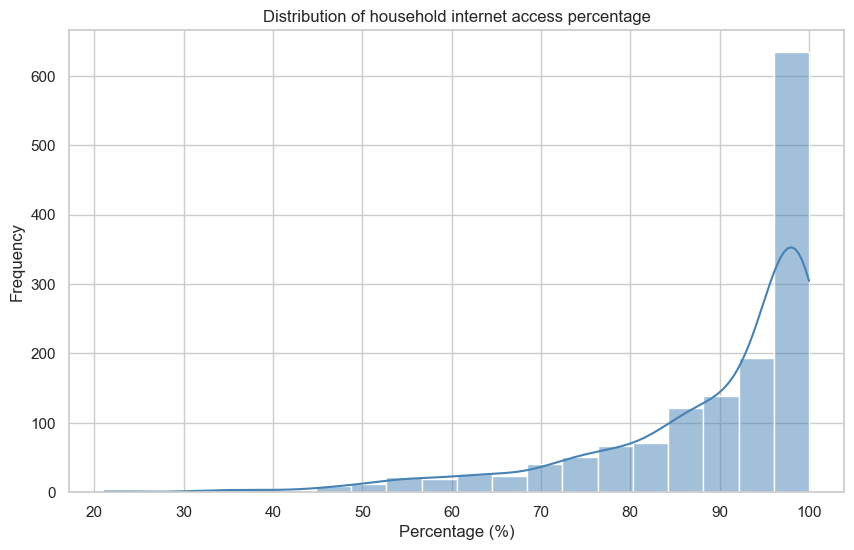

In [21]:
# Histogram of the indicator distribution
plt.figure()
sns.histplot(df["internet_access_pct"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of household internet access percentage")
plt.xlabel("Percentage (%)")
plt.ylabel("Frequency")
plt.show()




### Household types internet access
This cell compares distributions across household types in the most recent year using boxplots.
It examines medians, spread, and potential outliers for each group.
A group-level comparison that indicates which household types tend to have higher or lower internet access.


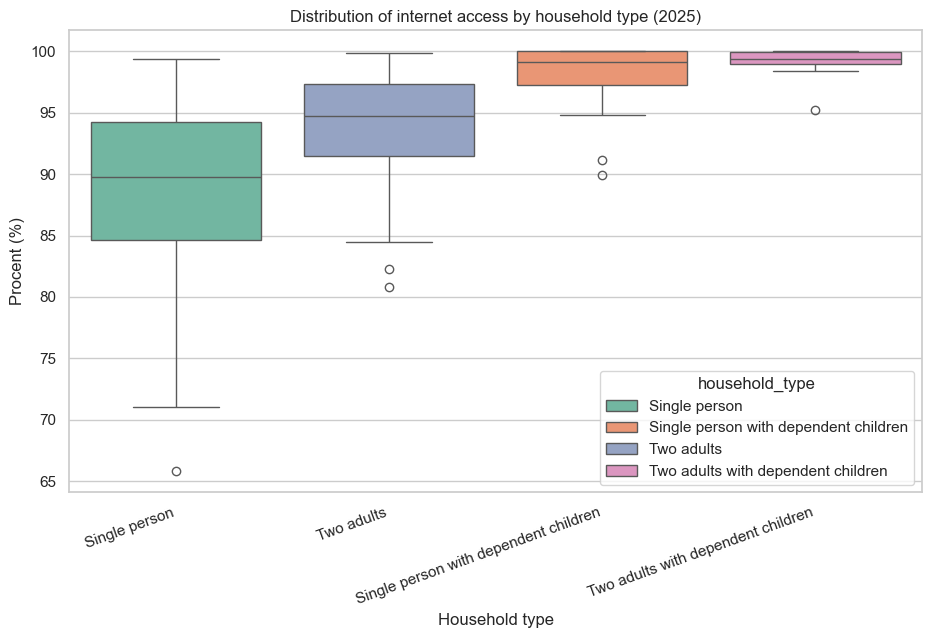

Interpretation: medians differ across groups; households with children tend to have higher access percentages.


In [22]:
# Boxplot by household type in the most recent year
order = (
    df_latest.groupby("household_type")["internet_access_pct"].mean()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_latest,
    x="household_type",
    y="internet_access_pct",
    order=order,
    hue="household_type",
    dodge=False,
    palette="Set2",
    legend=True,
)
plt.title(f"Distribution of internet access by household type ({latest_year})")
plt.xlabel("Household type")
plt.ylabel("Procent (%)")
plt.xticks(rotation=20, ha="right")
plt.show()

print(
    "Interpretation: medians differ across groups;"
    " households with children tend to have higher access percentages."
)


### Bar plot
This cell calculates and plots mean internet access for each household type in the most recent year.
It directly compares group averages.
Result: an easy-to-read ranking of household types by average access level.


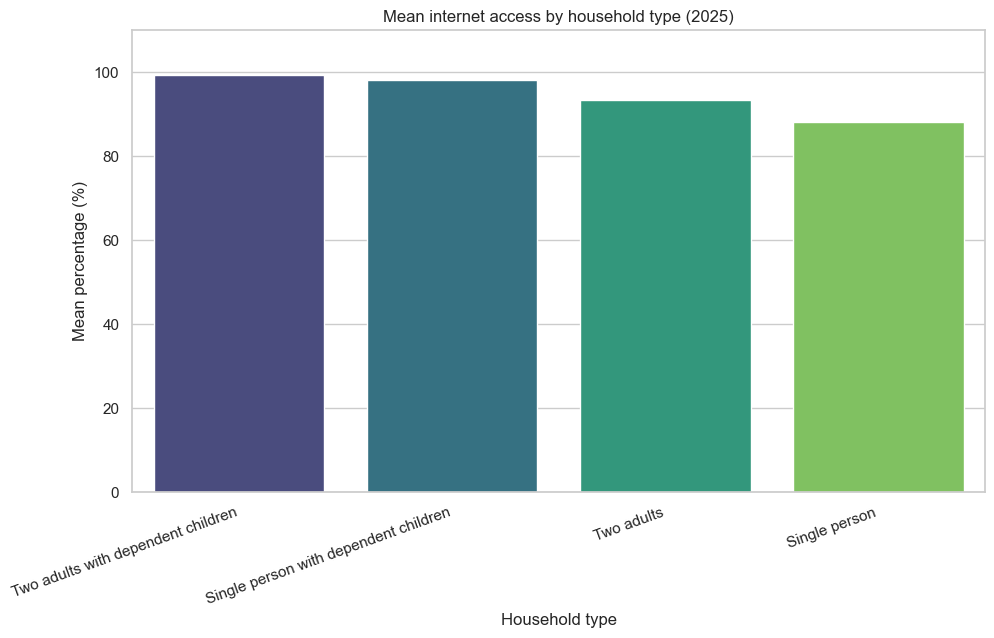

,household_type,internet_access_pct
3,Two adults with dependent children,99.289722
1,Single person with dependent children,98.164062
2,Two adults,93.424722
0,Single person,88.090833


In [24]:
# Bar chart: mean by household type (most recent year)
mean_by_household_latest = (
    df_latest.groupby("household_type", as_index=False)["internet_access_pct"].mean()
    .sort_values("internet_access_pct", ascending=False)
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=mean_by_household_latest,
    x="household_type",
    y="internet_access_pct",
    hue="household_type",
    dodge=False,
    palette="viridis",
    legend=False,
)
plt.title(f"Mean internet access by household type ({latest_year})")
plt.xlabel("Household type")
plt.ylabel("Mean percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 110)
plt.show()

mean_by_household_latest


### ECDF
This cell draws the empirical cumulative distribution function (ECDF).
It shows the cumulative share of observations below any given internet-access value.
It shows in which interval there are the most number of observations.

The 20% of observations has internet access percent less than 80.

The 80% of observations has internet access percent higher than 80.


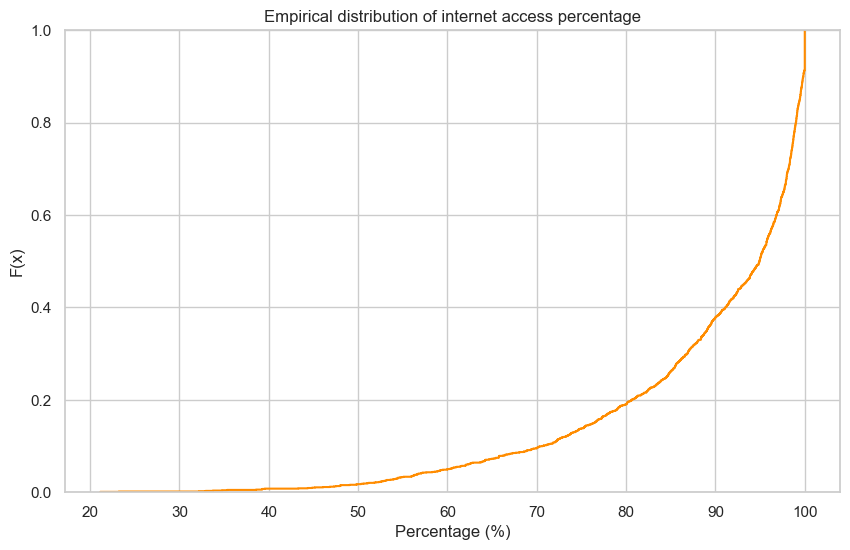

Interpretation: the ECDF confirms that a large share of observations lies in the high-value range of the indicator.


In [8]:
# Empirical distribution (ECDF)
plt.figure()
sns.ecdfplot(df["internet_access_pct"], color="darkorange")
plt.title("Empirical distribution of internet access percentage")
plt.xlabel("Percentage (%)")
plt.ylabel("F(x)")
plt.show()

print(
    "Interpretation: the ECDF confirms that a large share of observations"
    " lies in the high-value range of the indicator."
)


## III. Parameter Estimation and Confidence Intervals (Topic 4)

### Mean estimation in the most recent year
This cell estimates the mean internet access in the most recent year and builds a 95% confidence interval using the t-Student distribution.
It quantifies uncertainty around the sample mean.
An interval estimate for the population mean, interpreted as the range for the true average. 
We estimate the population mean using sample mean and estimate variability using the sample standard deviation, thats why we use t distribution. The 95% confidence interval means that if we repeat the experiment many times, take new samples, compute the mean - about the 95% of those intervals will contain the true population mean μ.


In [25]:
# Mean estimation in the most recent year + 95% CI (t-Student)
x = df_latest["internet_access_pct"].to_numpy()
n = len(x)
mean_x = x.mean()
std_x = x.std(ddof=1)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
se_mean = std_x / math.sqrt(n)
ci_mean = (mean_x - t_crit * se_mean, mean_x + t_crit * se_mean)

print(f"Estimated mean ({latest_year}): {mean_x:.3f}%")
print(f"95% CI for the population mean: [{ci_mean[0]:.3f}, {ci_mean[1]:.3f}]")
print("Interpretation: with 95% confidence, the true mean lies within this interval.")


Estimated mean (2025): 94.645%
95% CI for the population mean: [93.537, 95.752]
Interpretation: with 95% confidence, the true mean lies within this interval.


### How common high internet access is in the dataset.
This cell estimates the proportion of observations with internet access at or above 80% and computes a 95% confidence interval.
It counts how many cases satisfy the threshold and converts that to a proportion.
Measures how common is high internet access is in the dataset.
SE - measures how much the estimated proportion may vary from sample to sample.


In [26]:
# Estimate of a proportion: p = P(access >= 80%) in the most recent year
threshold = 80
success = (df_latest["internet_access_pct"] >= threshold).sum()
p_hat = success / n
z_crit = stats.norm.ppf(0.975)
se_p = math.sqrt(p_hat * (1 - p_hat) / n)
ci_prop = (p_hat - z_crit * se_p, p_hat + z_crit * se_p)

print(f"Selected threshold: {threshold}%")
print(f"Estimated proportion p-hat: {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"95% CI for the proportion: [{ci_prop[0]:.4f}, {ci_prop[1]:.4f}]")
print("Interpretation: the interval estimates the share of observations with high internet access.")


Selected threshold: 80%
Estimated proportion p-hat: 0.9571 (95.71%)
95% CI for the proportion: [0.9236, 0.9907]
Interpretation: the interval estimates the share of observations with high internet access.


## IV. Hypothesis Testing (Topic 5)

We test whether the mean internet access percentage in the most recent year equals 75%.

- $H_0: \mu = 75$
- $H_1: \mu 
eq 75$


### One-sample t-test
This cell performs a one-sample t-test for the most recent year - is the population mean internet access equal to 75%?

It computes the t statistic and p-value, then states the statistical decision (reject/fail to reject H0).

We are testing the hypothesis H0 - μ=75, and alternative hypothesis H1 μ≠75, average percent differs from 75%.
t-statistic show how far the sample average is from hypothesis.

p-value show the chance to get those values if H0 is true.
in ttest.pvalue < 0.05 we check H0 and choose do we accept or reject H0. With the 5% significance level.

In [33]:
mu0 = 75
ttest = stats.ttest_1samp(df_latest["internet_access_pct"], popmean=mu0)

print(f"One-sample t-test, year {latest_year}")
print(f"t statistic = {ttest.statistic:.4f}")
print(f"p-value = {ttest.pvalue:.6g}")

if ttest.pvalue < 0.05:
    print("Conclusion (alpha=0.05): reject H0. The mean differs significantly from 75%.")
else:
    print("Conclusion (alpha=0.05): fail to reject H0.")


One-sample t-test, year 2025
t statistic = 35.0755
p-value = 6.39123e-71
Conclusion (alpha=0.05): reject H0. The mean differs significantly from 75%.


## V. Tests for Categorical Variables (Topic 6)

We evaluate whether there is an association between:
- household type (`household_type`) and
- categoria de acces (`high_access`: $\geq 90\%$ vs. $<80\%$).


### Chi square test
This cell builds a categorical high-access variable (`>= 90%` vs `< 90%`), creates a contingency table with household type, and runs a chi-square test of independence.
It studies whether household type and high-access category are associated.
Using chi-square statistic, p-value, to make conclusion about dependence between the two categorical variables.

chi2 answers how big is difference with expected counts if data was independent.

p-value answers what is the chance of appearing of this pattern by random.


In [35]:
df_latest = df_latest.copy()
df_latest["high_access"] = np.where(df_latest["internet_access_pct"] >= 90, "Yes", "No")

contingency = pd.crosstab(df_latest["household_type"], df_latest["high_access"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print("Contingency table:")
display(contingency)

print(f"χ² = {chi2:.4f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p_chi2:.6g}")
print(f"Minimum expected frequency = {expected.min():.3f}")

if p_chi2 < 0.05:
    print("Conclusion: reject independence. There is an association between variables.")
else:
    print("Conclusion: there is not enough evidence for an association.")


Contingency table:


high_access,No,Yes
household_type,,
Single person,21,15
Single person with dependent children,1,31
Two adults,8,28
Two adults with dependent children,0,36


χ² = 45.3203
Degrees of freedom = 3
p-value = 7.91034e-10
Minimum expected frequency = 6.857
Conclusion: reject independence. There is an association between variables.


## VI. Analysis of Variance - ANOVA (Topic 7)

We compare `internet_access_pct` means across the 4 household types in the most recent year.

- $H_0$: all group means are equal
- $H_1$: at least one mean differs


### ANOVA requirements
This cell checks ANOVA assumptions before comparing group means.
In each household group (Shapiro-Wilk) and homogeneity of variances across groups (Levene).
Diagnostic evidence about whether classical ANOVA assumptions are well satisfied.
We will answer the question if different household types have different average internet access percentage.

Two required assumptions:
1. Inside each group data should be approximately normally distributed. (bell curve)
2. All groups should have similar spread. (variance)


In [36]:
# Checking ANOVA assumptions
anova_groups = [g["internet_access_pct"].values for _, g in df_latest.groupby("household_type")] # creating the groups

# Normality by groups (Shapiro-Wilk)
shapiro_rows = []
for name, g in df_latest.groupby("household_type"): # tesing normality (do the values look like normal distribution)
    stat, pval = stats.shapiro(g["internet_access_pct"])
    shapiro_rows.append({"household_type": name, "n": len(g), "W": stat, "p_value": pval})
shapiro_df = pd.DataFrame(shapiro_rows).sort_values("household_type")

# Homogeneity of variances (Levene) equality of variance
lev_stat, lev_p = stats.levene(*anova_groups, center="median")

print("Shapiro-Wilk by groups:")
display(shapiro_df)
print(f"Levene: stat={lev_stat:.4f}, p-value={lev_p:.6g}")


Shapiro-Wilk by groups:


,household_type,n,W,p_value
0,Single person,36,0.922300,1.471388e-02
1,Single person with dependent children,32,0.746947,4.747872e-06
2,Two adults,36,0.901628,3.781623e-03
3,Two adults with dependent children,36,0.691556,2.089931e-07


Levene: stat=14.1684, p-value=4.3414e-08


### ANOVA interpretation F statistics
This cell runs one-way ANOVA across household types for the most recent year.
Research question: are all group means equal, or does at least one differ?
Result: F statistic, p-value, and statistical conclusion, plus group means for interpretation.

F = between-group variance / within-group variance.
If F is near to 1, it means groups are similar.


In [30]:
# Classical ANOVA
f_stat, p_anova = stats.f_oneway(*anova_groups)

print(f"ANOVA: F = {f_stat:.4f}, p-value = {p_anova:.6g}")

if p_anova < 0.05:
    print("Conclusion: reject H0. There are significant differences between means.")
else:
    print("Conclusion: fail to reject H0.")

means_latest = (
    df_latest.groupby("household_type")["internet_access_pct"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("mean")
)
print("\nGroup means:")
display(means_latest)


ANOVA: F = 37.7381, p-value = 8.26353e-18
Conclusion: reject H0. There are significant differences between means.

Group means:


,mean
household_type,
Two adults with dependent children,99.289722
Single person with dependent children,98.164062
Two adults,93.424722
Single person,88.090833


### Post-hoc analysis
Because ANOVA can show that at least one mean differs, this cell identifies which pairs differ.
It runs pairwise Welch t-tests and applies Holm correction for multiple testing.
In result adjusted p-values and significance flags for each household-type pair.

Post-hoc comparisons indicate statistically significant differences between household types. However, differences among households with children are very small in magnitude (around 1 percentage point), suggesting limited practical importance.


In [31]:
# Post-hoc analysis (Welch pairwise comparisons + Holm correction)
grouped = {name: g["internet_access_pct"].values for name, g in df_latest.groupby("household_type")}
comparisons = []
for g1, g2 in itertools.combinations(grouped.keys(), 2):
    t_stat, p_val = stats.ttest_ind(grouped[g1], grouped[g2], equal_var=False)
    comparisons.append({"group_1": g1, "group_2": g2, "t_stat": t_stat, "p_raw": p_val})

posthoc = pd.DataFrame(comparisons)
reject, p_adj, _, _ = multipletests(posthoc["p_raw"], method="holm")
posthoc["p_adj_holm"] = p_adj
posthoc["significant_difference"] = reject
posthoc = posthoc.sort_values("p_adj_holm")

display(posthoc)


,group_1,group_2,t_stat,p_raw,p_adj_holm,significant_difference
2,Single person,Two adults with dependent children,-8.386956,5.695007e-10,3.417004e-09,True
0,Single person,Single person with dependent children,-7.184579,7.053938e-09,3.526969e-08,True
5,Two adults,Two adults with dependent children,-6.906304,3.755981e-08,1.502392e-07,True
3,Single person with dependent children,Two adults,4.984631,6.959945e-06,2.087984e-05,True
1,Single person,Two adults,-3.398587,1.218929e-03,2.437859e-03,True
4,Single person with dependent children,Two adults with dependent children,-2.379400,2.257643e-02,2.257643e-02,True


### ANOVA visualization
This cell visualizes ANOVA group differences with boxplots for the most recent year.
It supports interpretation of statistical test results by showing distribution overlap and separation.
A visual summary of between-group differences consistent with the ANOVA/post-hoc findings.


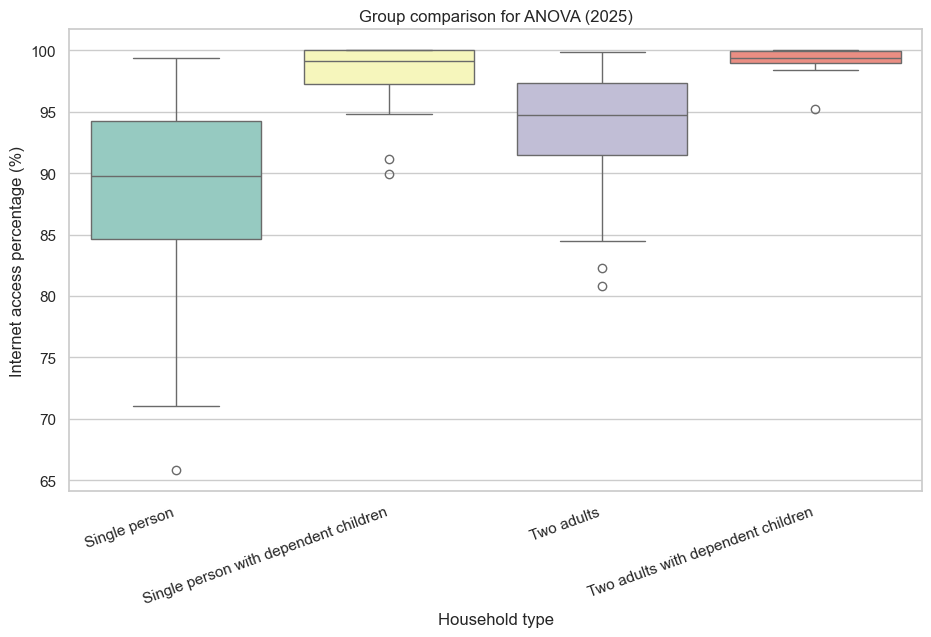

In [32]:
# Visualization for mean comparison (useful for ANOVA interpretation)
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_latest,
    x="household_type",
    y="internet_access_pct",
    hue="household_type",
    dodge=False,
    palette="Set3",
    legend=False,
)
plt.title(f"Group comparison for ANOVA ({latest_year})")
plt.xlabel("Household type")
plt.ylabel("Internet access percentage (%)")
plt.xticks(rotation=20, ha="right")
plt.show()


## VII. Conclusions and Recommendations

### Results Summary
The analysis shows that internet access among households in the examined dataset is very high. The estimated mean access level in the most recent year is close to the upper bound of the indicator, and the 95% confidence interval confirms that the average level of access remains consistently high across the sample. In the most recent year, the estimated mean and the 95% confidence interval indicate high values of the indicator.
The t-test shoqws that the mean differs significantly from hypothesis of 75%. The $\chi^2$ test revealed a statistically significant association between household type and bolonging to the high access category. ANOVA results showed diffferences between group means, that means that the average internet access differs between household groups. Post-hoc analysis shows which pair differ more significantly. 

### Contextual Interpretation
Results suggest that household structure is related to internet access levels. In particular, households with children tend to show higher average access levels.

### Limitations
- The dataset contains aggregated data, not at individual household level.
- Different data collection methods across countries or years.
- ANOVA assumptions normality and homogeneity are not perfectly satisfied, so interpretation should be cautious, but still remains informative.

### Possible Extensions
- Separate analyses by countries.
- Regression models that account for country-specific effects or time trends.
